# Digits 손글씨 숫자 이미지 분류

## 데이터셋 설명
- `sklearn.datasets.load_digits()` 데이터셋을 사용함.
- 0부터 9까지 손글씨 숫자 이미지를 모아 둔 scikit-learn 내장 예제 데이터임.
- 각 이미지는 `8 x 8` 크기의 작은 흑백 이미지임.
- 픽셀 값은 보통 `0~16` 범위의 밝기 값임.
  - 값이 작으면 어두운 부분
  - 값이 크면 밝은 부분
- target은 이미지가 어떤 숫자인지를 나타냄.
  - 예: target이 `3`이면 해당 이미지는 숫자 3임.

## 중요한 데이터 모양
- `digits.images`
  - 모양: `(샘플 수, 8, 8)`
  - 이미지를 눈으로 확인할 때 사용함.
- `digits.data`
  - 모양: `(샘플 수, 64)`
  - 8 x 8 이미지를 한 줄로 펼친 데이터임.
  - 머신러닝 모델은 이 64개 숫자를 feature로 사용함.
- `digits.target`
  - 모양: `(샘플 수,)`
  - 각 이미지의 정답 숫자임.

## 핵심 이해
- 이미지는 결국 숫자 배열임.
- 모델은 그림을 사람처럼 보는 것이 아니라, 64개 픽셀 밝기 feature를 보고 class를 예측함.
- `reshape(8, 8)`은 모델 학습용이 아니라, 64개 숫자를 다시 이미지처럼 보기 위해 사용하는 것임.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Digits 데이터셋은 8x8 손글씨 숫자 이미지 데이터임.
digits = load_digits()

# digits.data는 8x8 이미지를 64개 feature로 펼친 2차원 배열임.
# 모델 학습에는 이 2차원 배열을 사용함.
digits_df = pd.DataFrame(
    digits.data,
    columns=[f'pixel_{idx}' for idx in range(digits.data.shape[1])]
)
digits_df['target'] = digits.target

X = digits_df.drop('target', axis=1)
y = digits_df['target']

print('digits.images 모양:', digits.images.shape)
print('digits.data 모양:', digits.data.shape)
print('digits.target 모양:', digits.target.shape)
print('DataFrame 모양:', digits_df.shape)
print('target 종류:', sorted(y.unique()))
display(digits_df.head())


digits.images 모양: (1797, 8, 8)
digits.data 모양: (1797, 64)
digits.target 모양: (1797,)
DataFrame 모양: (1797, 65)
target 종류: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 문제 1. 이미지 데이터 구조 확인

Digits 데이터가 이미지 형태와 모델 학습용 표 형태를 모두 가지고 있다는 점을 확인하세요.

### 요구사항
- 첫 번째 샘플의 target 출력
- 첫 번째 샘플의 `8 x 8` 픽셀 배열을 DataFrame으로 출력
- `plt.imshow()`로 첫 번째 이미지를 시각화
- `cmap='gray_r'` 사용

### 힌트
- `digits.images[0]`은 첫 번째 이미지를 8 x 8 배열로 보여줌.
- `digits.data[0]`은 같은 이미지를 64개 숫자로 펼친 것임.
- `imshow()`는 2차원 숫자 배열을 이미지처럼 보여주는 함수임.
- `gray_r`은 숫자가 큰 픽셀을 진하게 보이게 해 손글씨를 보기 쉽게 함.


첫번째 샘플의 target(정답): 0
 8 x 8 픽셀 배열 


,0,1,2,3,4,5,6,7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0
1,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0
2,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0
3,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0
4,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0
5,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0
6,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0
7,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0


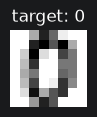

In [9]:
# 작성: 첫 번째 샘플의 target을 출력하세요.
sample_idx = 0

print("첫번째 샘플의 target(정답):", digits.target[sample_idx])

# 작성: 첫 번째 샘플의 8 x 8 픽셀 배열을 DataFrame으로 출력하세요.
print(' 8 x 8 픽셀 배열 ')
display(pd.DataFrame(digits.images[sample_idx]))

# 작성: plt.imshow()로 첫 번째 이미지를 시각화하세요.

plt.figure(figsize=(1,1))
plt.imshow(digits.images[sample_idx], cmap = 'gray_r')
plt.title(f'target: {digits.target[sample_idx]}')
plt.axis('off')
plt.show()

## 문제 2. 데이터 분리와 스케일링

64개 픽셀 feature를 사용해 숫자를 분류할 수 있도록 학습/평가 데이터를 나누고 스케일링하세요.

### 요구사항
- `train_test_split()` 사용
- `test_size=0.2`, `random_state=42`, `stratify=y` 사용
- `StandardScaler()` 사용
- 학습 데이터에는 `fit_transform()`, 평가 데이터에는 `transform()` 사용
- 분리 결과 shape 출력

### 힌트
- `X`는 이미 `(샘플 수, 64)` 형태의 표 데이터임.
- 각 컬럼은 이미지의 특정 위치에 해당하는 픽셀 밝기 feature임.
- KNN과 Logistic Regression은 feature 스케일 영향을 받을 수 있으므로 스케일링을 적용함.


In [10]:
# 작성: train_test_split()으로 학습/평가 데이터를 분리하세요.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

# 작성: StandardScaler()로 학습/평가 데이터를 스케일링하세요.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 작성: 분리 결과 shape를 출력하세요.
print(X_train_scaled.shape,y_train.shape)
print(X_test_scaled.shape,y_test.shape)

(1437, 64) (1437,)
(360, 64) (360,)


## 문제 3. 분류 모델 3개 성능 비교

KNN, Logistic Regression, Random Forest를 학습하고 평가 데이터 accuracy를 비교하세요.

### 요구사항
- `KNeighborsClassifier(n_neighbors=5)` 사용
- `LogisticRegression(max_iter=5000, random_state=42)` 사용
- `RandomForestClassifier(n_estimators=200, random_state=42)` 사용
- 결과 컬럼: `model`, `train_accuracy`, `test_accuracy`
- 결과를 DataFrame으로 출력

### 힌트
- KNN은 64개 픽셀 feature가 비슷한 이미지끼리 가까운 이웃으로 봄.
- Logistic Regression은 각 픽셀 feature에 가중치를 두어 class를 구분함.
- Random Forest는 여러 결정트리가 픽셀 feature 조건을 나눠가며 숫자를 분류함.


In [14]:
# 작성: KNN, Logistic Regression, Random Forest 모델을 딕셔너리로 준비하세요.
models = {
    'knn': KNeighborsClassifier(n_neighbors=5),
    'logistic_regression': LogisticRegression(max_iter=5000, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

# 작성: 반복문으로 모델을 학습하고 train/test accuracy를 results에 저장하세요.
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)    # train 데이터 학습
    y_pred = model.predict(X_test_scaled) # test 예측값

    results.append({
        'model': name,
        'train_accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
        'test_accuracy': accuracy_score(y_test, y_pred)
    })

# 작성: 결과를 DataFrame으로 출력하세요.
result_df = pd.DataFrame(results)
display(result_df)

,model,train_accuracy,test_accuracy
0,knn,0.983994,0.963889
1,logistic_regression,0.999304,0.972222
2,random_forest,1.000000,0.963889


## 문제 4. 예측 결과를 이미지와 함께 확인

가장 좋은 모델을 선택하고, 평가 데이터 일부의 실제 숫자와 예측 숫자를 이미지로 확인하세요.

### 요구사항
- 문제 3 결과에서 가장 좋은 모델 선택
- `classification_report()` 출력
- 평가 데이터 앞 10개를 2행 5열로 시각화
- 각 이미지 제목에 실제값과 예측값 표시

### 힌트
- `X_test`의 한 행은 64개 픽셀 값으로 펼쳐진 상태임.
- 이미지를 다시 보려면 `to_numpy().reshape(8, 8)`을 사용함.
- 이 `reshape()`는 모델 입력을 바꾸는 것이 아니라, 사람이 보기 좋게 다시 8 x 8 이미지로 되돌리는 과정임.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



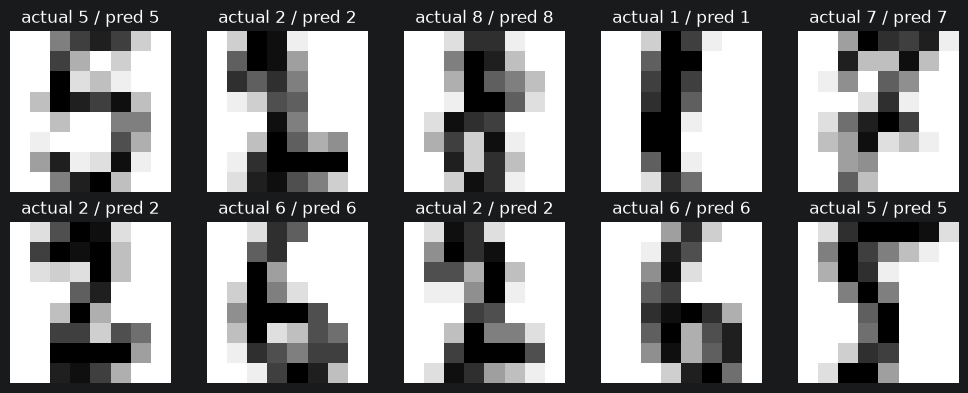

In [18]:
# 작성: result_df에서 평가 accuracy가 가장 높은 모델 이름을 찾으세요.
best_model_name = result_df.iloc[0]['model']

best_model = models[best_model_name]

# 작성: 선택한 모델로 평가 데이터를 예측하고 classification_report()를 출력하세요.
y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# 작성: 평가 데이터 앞 10개 이미지를 actual/pred와 함께 시각화하세요.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, row_idx in zip(axes.ravel(), range(10)):
    # X_test의 한 행은 64개 픽셀 값이므로, 시각화를 위해 8x8 이미지로 되돌림.
    image = X_test.iloc[row_idx].to_numpy().reshape(8, 8)
    actual = y_test.iloc[row_idx]
    pred = y_pred[row_idx]

    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'actual {actual} / pred {pred}')
    ax.axis('off')

plt.tight_layout()
plt.show()